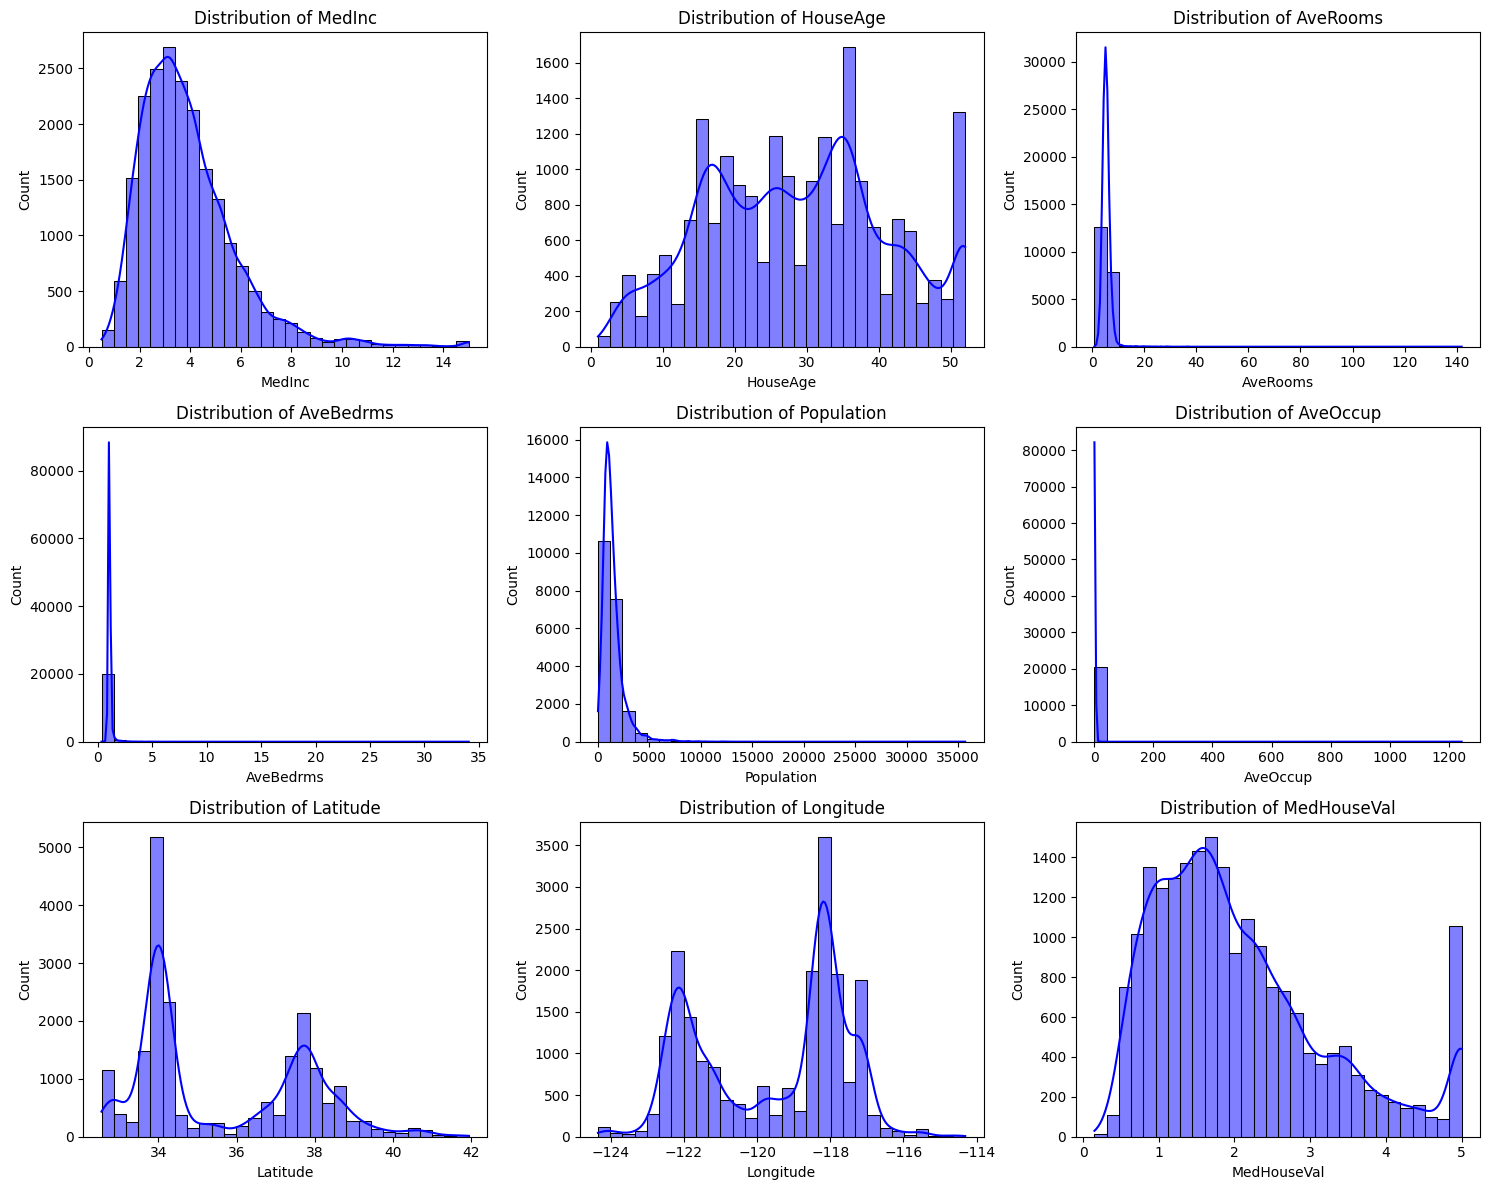

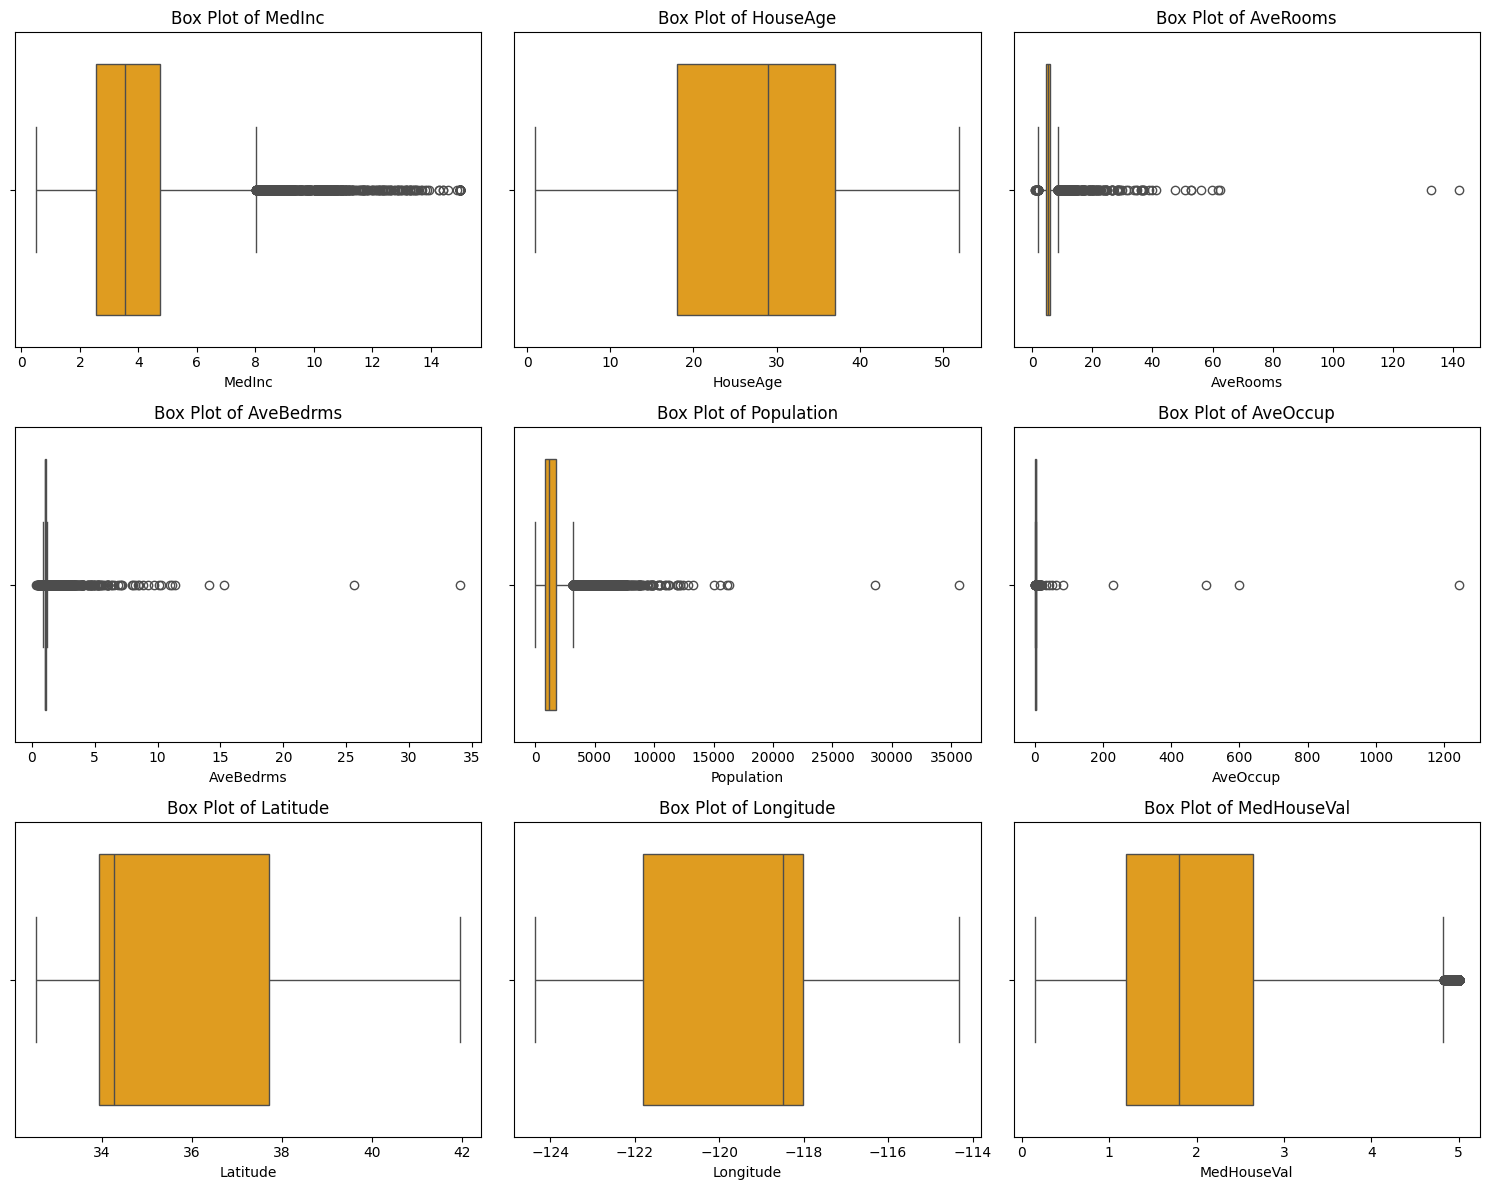

--- Outlier Detection ---
MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVal: 1071 outliers

--- Dataset Summary ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Lat

In [6]:
#prg 1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. Load the dataset
data = fetch_california_housing(as_frame=True)
housing_df = data.frame

# 2. Identify numerical features
numerical_features = housing_df.columns

# 3. Plot Histograms (Distributions)
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(housing_df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# 4. Generate Box Plots (Outliers)
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=housing_df[feature], color='orange')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# 5. Outlier Detection using IQR
print("--- Outlier Detection ---")
for feature in numerical_features:
    Q1 = housing_df[feature].quantile(0.25)
    Q3 = housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((housing_df[feature] < lower_bound) | (housing_df[feature] > upper_bound)).sum()
    print(f"{feature}: {outlier_count} outliers")

print("\n--- Dataset Summary ---")
print(housing_df.describe())

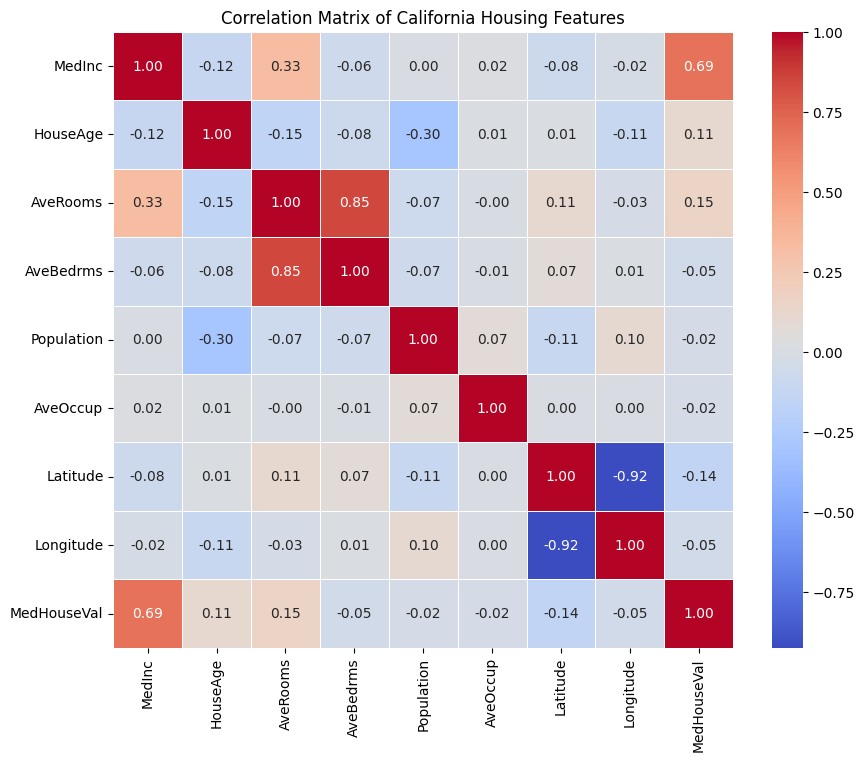

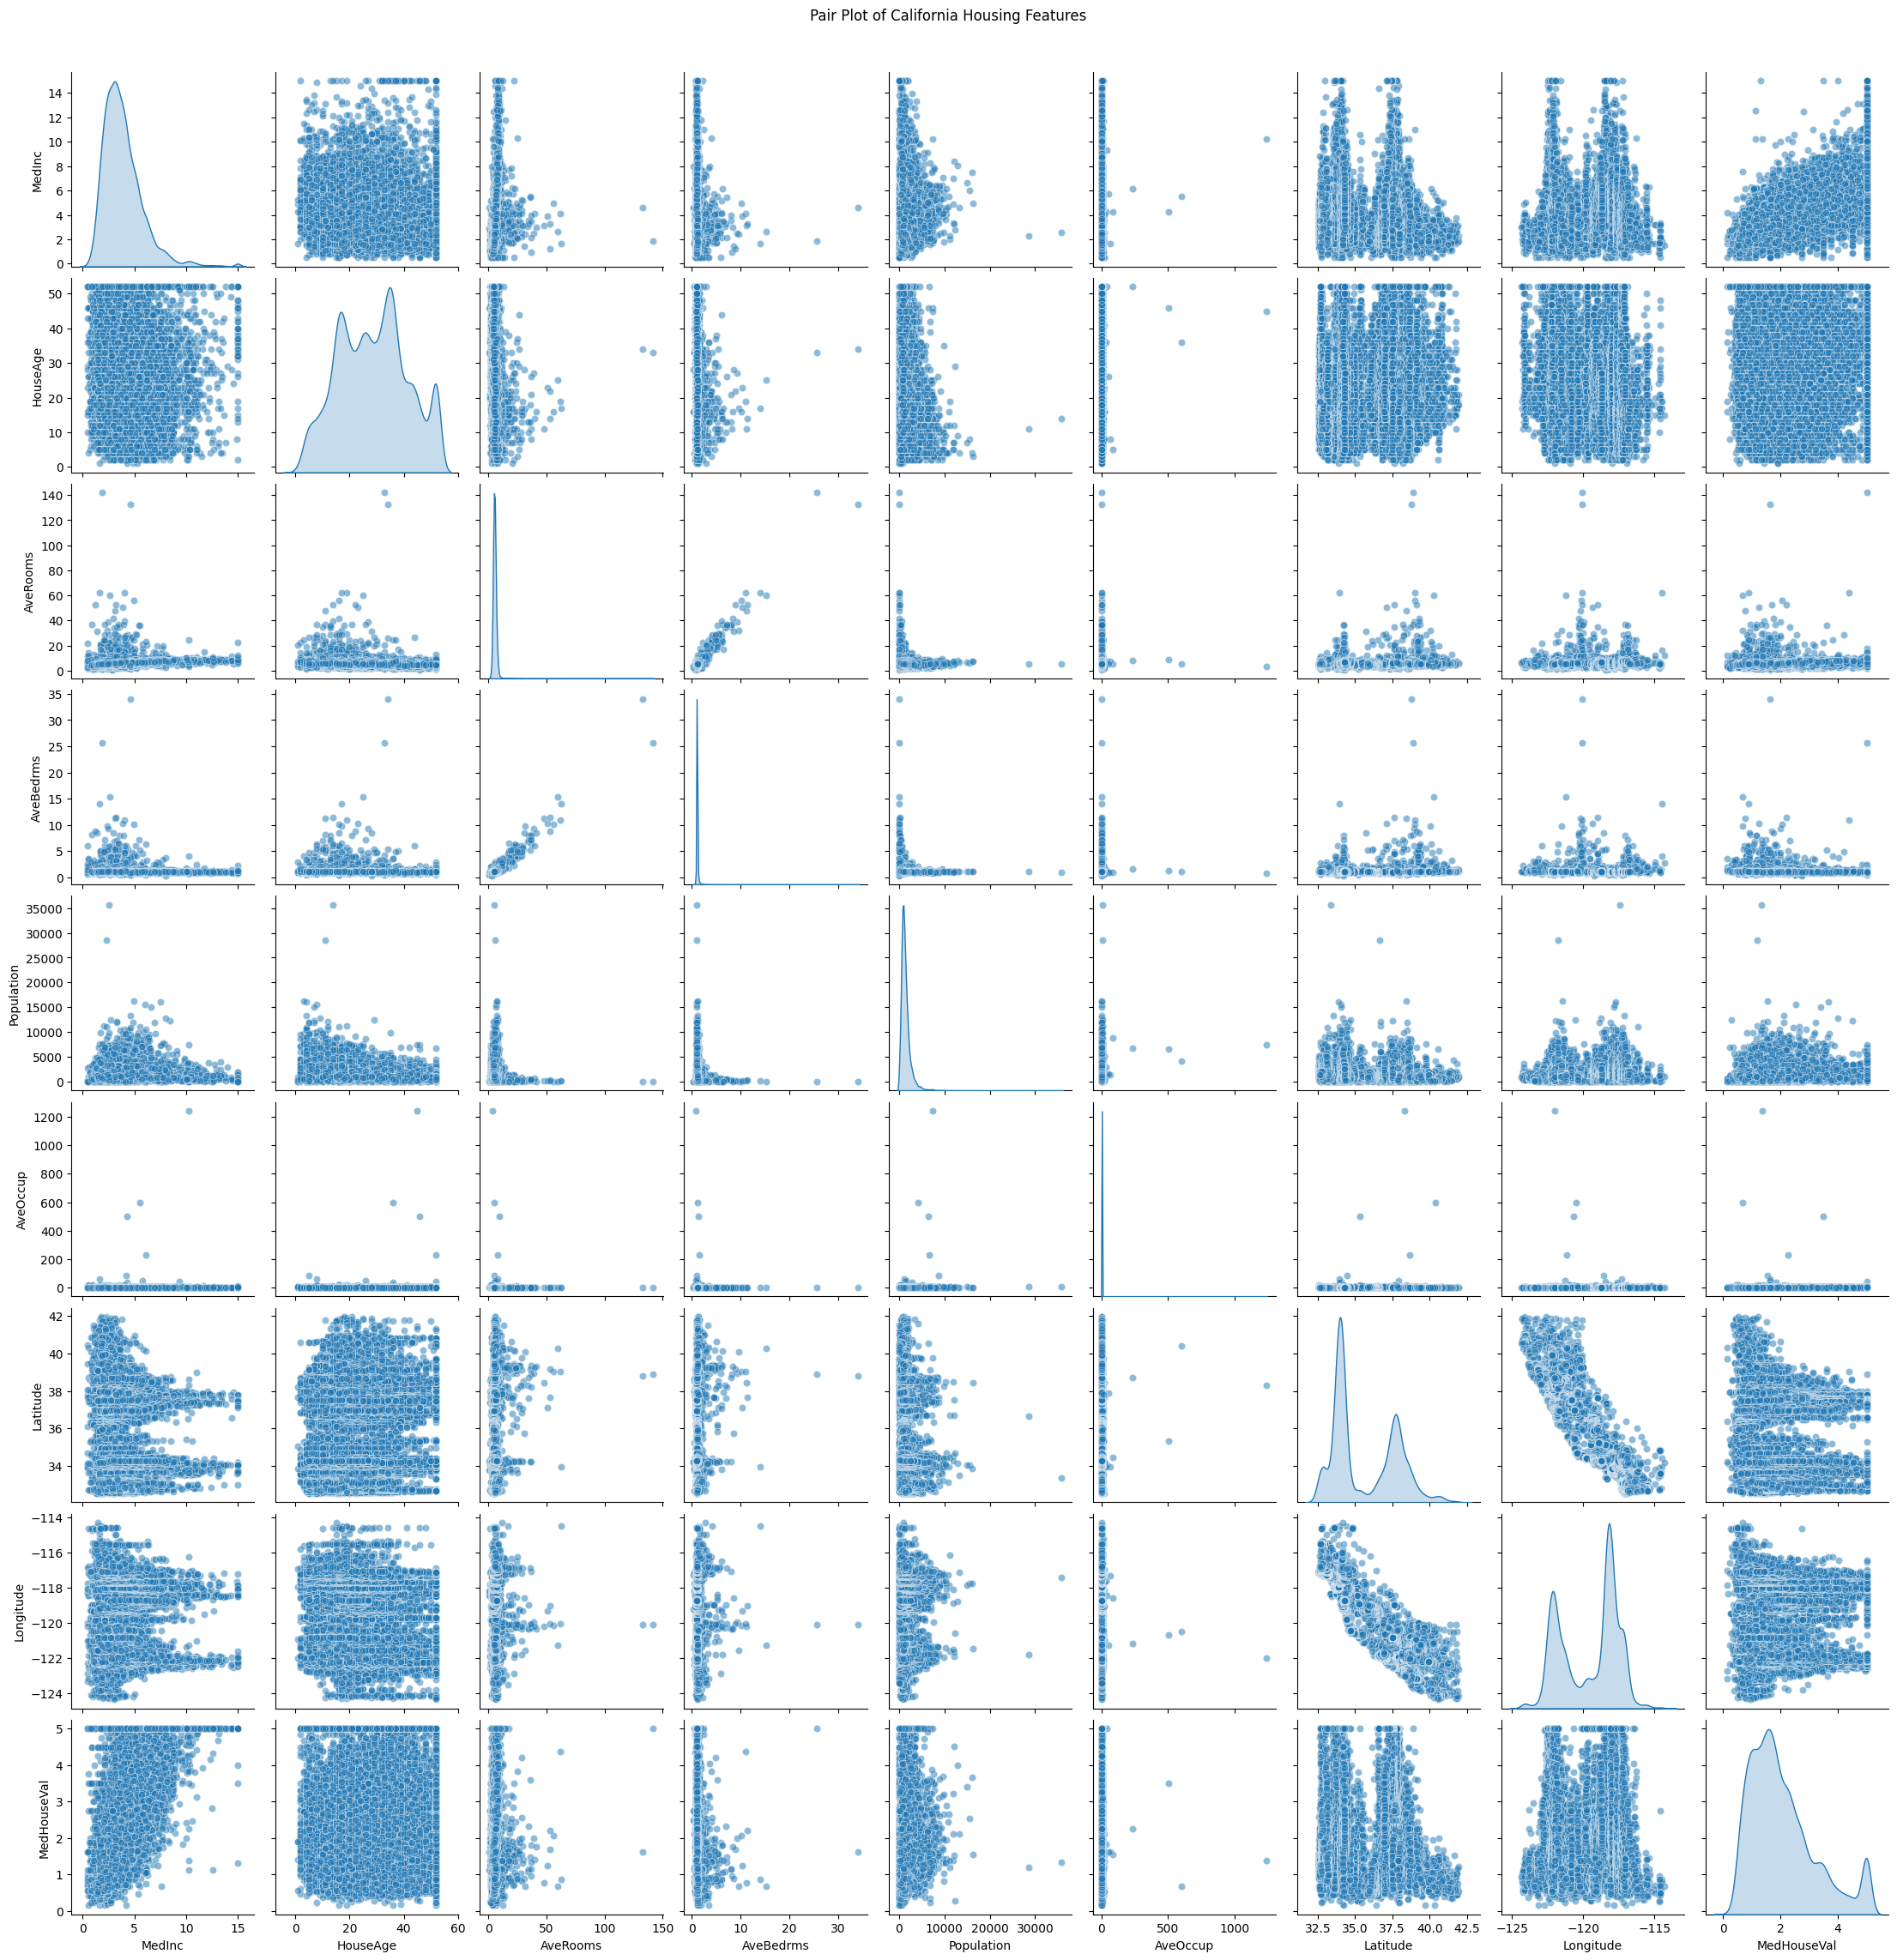

In [14]:
#prg 2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Step 1: Load the California Housing Dataset
california_data = fetch_california_housing(as_frame=True)
data = california_data.frame

# Step 2: Compute the correlation matrix
correlation_matrix = data.corr()

# Step 3: Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of California Housing Features')
plt.show()

# Step 4: Create a pair plot to visualize pairwise relationships
sns.pairplot(data, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot of California Housing Features', y=1.02)
plt.show()


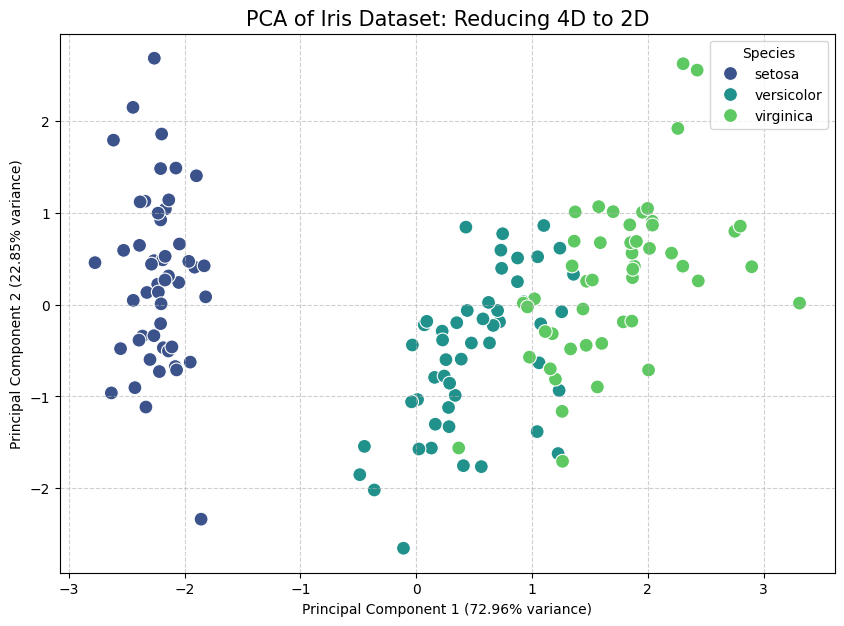

Total Variance Captured by these 2 components: 95.81%


In [10]:
#prg 3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
iris = load_iris()
X = iris.data  # The 4 numerical features
y = iris.target  # The species labels (0, 1, 2)
feature_names = iris.feature_names
target_names = iris.target_names

# 2. Standardize the data (CRITICAL for PCA)
# PCA is sensitive to the scale of data; this makes mean=0 and variance=1
X_scaled = StandardScaler().fit_transform(X)

# 3. Apply PCA
# We reduce 4D data (4 features) down to 2D so we can plot it on a graph
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Create a clean DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Species'] = [target_names[i] for i in y]

# 5. Visualize the results
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Species', palette='viridis', s=100)

# Add titles and labels
plt.title('PCA of Iris Dataset: Reducing 4D to 2D', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Show the "Importance" of each component
print(f"Total Variance Captured by these 2 components: {np.sum(pca.explained_variance_ratio_):.2%}")

In [18]:
#prg 4
import pandas as pd

def find_s_algorithm(file_path):
    # Load dataset
    data = pd.read_csv(file_path)
    print("Training data:\n", data)

    # Separate features and target
    attributes = data.columns[:-1]
    target = data.columns[-1]

    # Initialize hypothesis with the first 'Yes' instance
    # Find-S starts with the most specific hypothesis possible
    hypothesis = None
    
    for index, row in data.iterrows():
        if row[target] == 'Yes':
            if hypothesis is None:
                # Set the first positive instance as the initial hypothesis
                hypothesis = list(row[attributes])
            else:
                # Compare current hypothesis with new positive instance
                for i in range(len(attributes)):
                    if hypothesis[i] != row[attributes][i]:
                        # Generalize the attribute if it doesn't match
                        hypothesis[i] = '?'
    
    return hypothesis

# To run this, ensure 'training_data.csv' exists in your folder
try:
    file_path = 'training_data.csv'
    final_h = find_s_algorithm(file_path)
    print("\nThe final maximally specific hypothesis is:", final_h)
except FileNotFoundError:
    print("Error: Please provide a valid 'training_data.csv' file.")

Error: Please provide a valid 'training_data.csv' file.


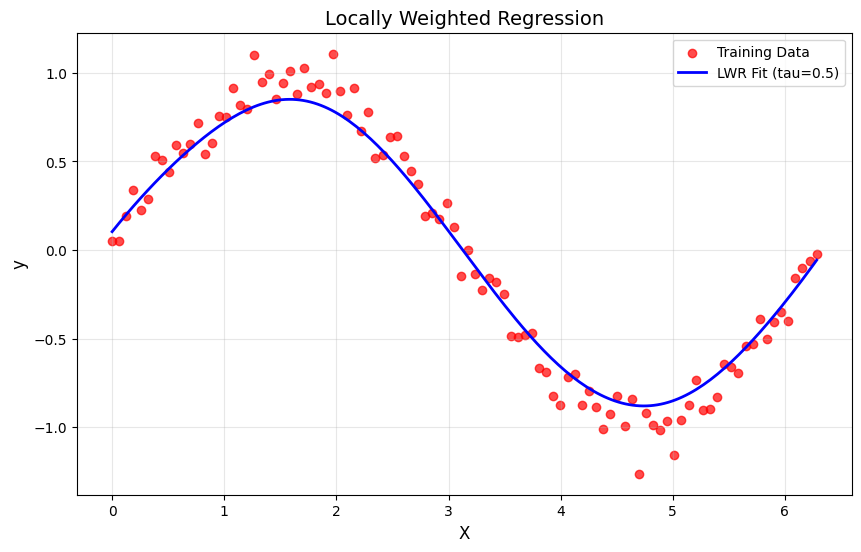

In [26]:
#prg 6
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau ** 2))

def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    X_transpose_W = X.T @ W
    theta = np.linalg.inv(X_transpose_W @ X) @ X_transpose_W @ y
    return x @ theta

np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)
X_bias = np.c_[np.ones(X.shape), X]

x_test = np.linspace(0, 2 * np.pi, 200)
x_test_bias = np.c_[np.ones(x_test.shape), x_test]
tau = 0.5
y_pred = np.array([locally_weighted_regression(xi, X_bias, y, tau) for xi in x_test_bias])

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Training Data', alpha=0.7)
plt.plot(x_test, y_pred, color='blue', label=f'LWR Fit (tau={tau})', linewidth=2)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Locally Weighted Regression', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()


Model Accuracy: 94.74%
Predicted Class for the new sample: Benign


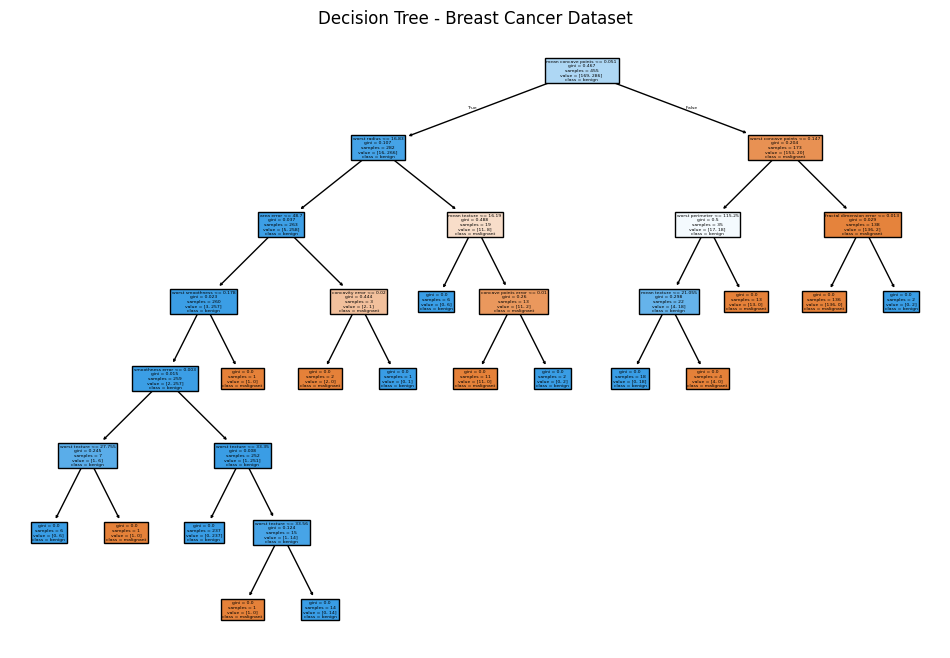

In [22]:
#prg8
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
new_sample = np.array([X_test[0]])
prediction = clf.predict(new_sample)

prediction_class = "Benign" if prediction == 1 else "Malignant"
print(f"Predicted Class for the new sample: {prediction_class}")

plt.figure(figsize=(12,8))
tree.plot_tree(clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title("Decision Tree - Breast Cancer Dataset")
plt.show()


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\sathv\scikit_learn_data
Accuracy: 80.83%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       0.33      0.67      0.44         3
           3       1.00      0.00      0.00         5
           4       1.00      0.50      0.67         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      0.67      0.80         3
           9       1.00      0.75      0.86         4
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         1
          12       0.40      1.00      0.57         4
          13       1.00      0.80      0.89         5
          14       1.00      0.40      0.57         5
          15       0.67      1.00

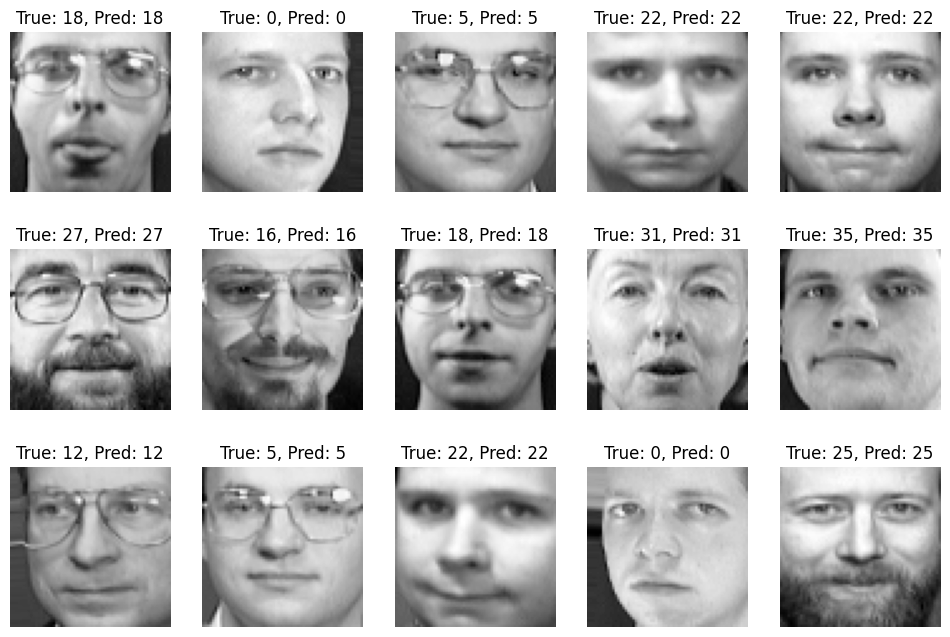

In [24]:
#prg9
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cross_val_accuracy = cross_val_score(gnb, X, y, cv=5, scoring='accuracy')
print(f'\nCross-validation accuracy: {cross_val_accuracy.mean() * 100:.2f}%')

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, image, label, prediction in zip(axes.ravel(), X_test, y_test, y_pred):
    ax.imshow(image.reshape(64, 64), cmap=plt.cm.gray)
    ax.set_title(f"True: {label}, Pred: {prediction}")
    ax.axis('off')

plt.show()

